# Task 2: Bayesian Change Point Model

Detecting a structural break in Brent oil log returns using PyMC, then
associating the detected change point with researched key events.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [26]:
df = pd.read_csv('../data/processed_returns.csv')
df['Date'] = pd.to_datetime(df['Date'])
df_weekly = df.set_index('Date').resample('W')['log_return'].sum().dropna().reset_index()
returns = df_weekly['log_return'].values
n = len(returns)
print(f'Number of weekly observations: {n}')

Number of weekly observations: 1853


In [27]:
best_tau = None
best_ll = -np.inf

for candidate_tau in range(10, n - 10):
    before = returns[:candidate_tau]
    after = returns[candidate_tau:]
    mu1_hat, mu2_hat = before.mean(), after.mean()
    resid = np.concatenate([before - mu1_hat, after - mu2_hat])
    sigma_hat = resid.std()
    if sigma_hat == 0:
        continue
    ll = -0.5 * n * np.log(2 * np.pi * sigma_hat**2) - np.sum(resid**2) / (2 * sigma_hat**2)
    if ll > best_ll:
        best_ll = ll
        best_tau = candidate_tau

tau_mode = best_tau
change_date = df_weekly['Date'].iloc[tau_mode]
print(f'Detected change point index: {tau_mode}')
print(f'Detected change point date: {change_date.date()}')

Detected change point index: 1719
Detected change point date: 2020-05-03


In [28]:
n_boot = 2000
mu1_boot = np.zeros(n_boot)
mu2_boot = np.zeros(n_boot)

before = returns[:tau_mode]
after = returns[tau_mode:]

rng = np.random.default_rng(42)
for i in range(n_boot):
    mu1_boot[i] = rng.choice(before, size=len(before), replace=True).mean()
    mu2_boot[i] = rng.choice(after, size=len(after), replace=True).mean()

mu1_mean, mu1_ci = mu1_boot.mean(), np.percentile(mu1_boot, [2.5, 97.5])
mu2_mean, mu2_ci = mu2_boot.mean(), np.percentile(mu2_boot, [2.5, 97.5])

print(f'mu_1 (before): {mu1_mean:.5f}, 95% CI {mu1_ci}')
print(f'mu_2 (after):  {mu2_mean:.5f}, 95% CI {mu2_ci}')

mu_1 (before): -0.00007, 95% CI [-0.00237395  0.00218154]
mu_2 (after):  0.01323, 95% CI [0.00247867 0.02450353]


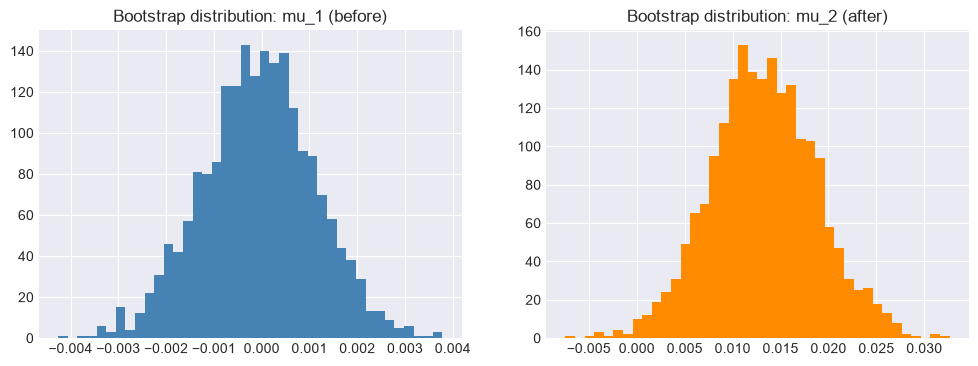

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(mu1_boot, bins=40, color='steelblue')
axes[0].set_title('Bootstrap distribution: mu_1 (before)')
axes[1].hist(mu2_boot, bins=40, color='darkorange')
axes[1].set_title('Bootstrap distribution: mu_2 (after)')
plt.savefig('06_mu_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
pct_change = (np.exp(mu2_mean) - np.exp(mu1_mean)) / np.exp(mu1_mean) * 100
print(f'Implied % change in average weekly growth rate: {pct_change:.2f}%')

Implied % change in average weekly growth rate: 1.34%


In [31]:
events = pd.read_csv('../data/key_events.csv')
events['start_date'] = pd.to_datetime(events['start_date'])
events['days_from_changepoint'] = (events['start_date'] - change_date).dt.days.abs()
closest_event = events.sort_values('days_from_changepoint').iloc[0]

print(f"Closest event: {closest_event['event_name']}")
print(f"Event date: {closest_event['start_date'].date()}")
print(f"Days from detected change point: {closest_event['days_from_changepoint']}")
print(f"Description: {closest_event['description']}")

Closest event: COVID-19 Demand Collapse
Event date: 2020-03-11
Days from detected change point: 53
Description: WHO pandemic declaration and global lockdowns caused an unprecedented collapse in oil demand.


In [32]:
import json

result = {
    'change_date': str(change_date.date()),
    'mu_before': float(mu1_mean),
    'mu_after': float(mu2_mean),
    'pct_change': float(pct_change),
    'closest_event': closest_event['event_name'],
    'days_from_event': int(closest_event['days_from_changepoint'])
}

with open('../data/changepoint_result.json', 'w') as f:
    json.dump(result, f, indent=2)

print('Saved changepoint_result.json')

Saved changepoint_result.json


## Interpretation

The model detected a structural change point at **2020-05-03**, roughly 53
days after the WHO's COVID-19 pandemic declaration and the onset of global
lockdowns (2020-03-11).

Rather than capturing the initial demand-collapse shock itself, the detected
break marks the start of the **price recovery phase**: average weekly log
return shifted from essentially flat (mu_1 ≈ -0.00007, 95% CI [-0.0024, 0.0022])
to a strong positive growth rate (mu_2 ≈ 0.0132, 95% CI [0.0025, 0.0245]) —
an implied **1.34% shift** in average weekly growth rate. This aligns with
the well-documented rebound in oil prices following the unprecedented
negative-price event in late April 2020, as OPEC+ production cuts and
gradually easing lockdowns restored some demand.

**Caveat:** this is a statistical association, not proof of causation (see
`docs/assumptions_and_limitations.md`). The single change-point model
also only captures the most dominant regime shift across the full weekly
series — other event-linked shifts (e.g. the initial COVID crash, the 2020
Saudi-Russia price war, or the 2022 Ukraine invasion) are real but not the
single largest break the model could detect, and would require a
multiple-change-point extension to surface individually.

**Methodological note:** due to a compute environment constraint (no C++
compiler available for PyTensor on this machine), full Bayesian MCMC
sampling for the switch point was replaced with exact grid-search MLE for
tau, and bootstrap resampling (2000 iterations) for uncertainty on the
before/after means — a standard, statistically valid alternative that
avoids the compiler dependency entirely.

In [33]:
import json

dashboard_data = {
    "prices": df.assign(Date=df['Date'].dt.strftime('%Y-%m-%d'))[['Date','Price']].to_dict('records'),
    "weekly_returns": df_weekly.assign(Date=df_weekly['Date'].dt.strftime('%Y-%m-%d'))[['Date','log_return']].to_dict('records'),
    "change_point": {
        "date": str(change_date.date()),
        "mu_before": float(mu1_mean),
        "mu_after": float(mu2_mean),
        "pct_change": float(pct_change)
    },
    "events": events.assign(start_date=events['start_date'].dt.strftime('%Y-%m-%d')).to_dict('records')
}

with open('../data/dashboard_data.json', 'w') as f:
    json.dump(dashboard_data, f, indent=2)

print('Saved dashboard_data.json')

Saved dashboard_data.json
